# FINd — Optimisation 

Six single-method variants of the original FINDHasher, each isolating one NumPy vectorisation.

| Variant | Method changed | Technique |
|---------|---------------|-----------|
| v1_luminance | fillFloatLumaFromBufferImage | np.asarray + vectorised luma |
| v2_boxfilter | boxFilter | integral image (summed-area table) |
| v3_median | dctOutput2hash | np.median replaces Torben |
| v4_hash | dctOutput2hash | vectorised threshold + axis reversal |
| v5_decimate | decimateFloat | np.arange + np.ix_ fancy indexing |
| v6_dct | dct64To16 | NumPy @ matrix multiply |

In [ ]:
import sys, random, timeit, tracemalloc, statistics, io, cProfile, pstats
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../").resolve()))
from FINd import FINDHasher
from optimisations.v1_luminance import FINDHasher_v1_luminance
from optimisations.v2_boxfilter import FINDHasher_v2_boxfilter
from optimisations.v3_median    import FINDHasher_v3_median
from optimisations.v4_hash      import FINDHasher_v4_hash
from optimisations.v5_decimate  import FINDHasher_v5_decimate
from optimisations.v6_dct       import FINDHasher_v6_dct

random.seed(42)
np.random.seed(42)

MEME_DIR   = Path(".../Hilary_term /DS in practice TA/Summative /meme_images") #  Update this path to your local directory containing the meme images
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

all_images = sorted(MEME_DIR.glob("*.jpg"))

VARIANTS = [
    ("Original",    FINDHasher()),
    ("v1_luminance", FINDHasher_v1_luminance()),
    ("v2_boxfilter", FINDHasher_v2_boxfilter()),
    ("v3_median",    FINDHasher_v3_median()),
    ("v4_hash",      FINDHasher_v4_hash()),
    ("v5_decimate",  FINDHasher_v5_decimate()),
    ("v6_dct",       FINDHasher_v6_dct()),
]
print(f"Images: {len(all_images):,}  |  Variants: {len(VARIANTS)}")

Images: 55,972  |  Variants: 7


---
## Variant Descriptions

Each variant changes exactly one method. All other methods are copied byte-for-byte from the original `FINDHasher`.

### v1\_luminance — Vectorised RGB-to-Luminance

**Method changed:** `fillFloatLumaFromBufferImage`

Previous behaviour: Per-pixel `getpixel()` call inside a nested Python loop — 625,000 interpreter-level calls for a 250×250 image.

**Change**: Replaced with `np.asarray(rgb_image, dtype=np.float64)` to read the full pixel buffer in one C-level call, followed by a vectorised BT.601 dot product across all pixels simultaneously.






### v2\_boxfilter — Integral Image (Summed-Area Table)

**Method changed:** `boxFilter`

Previous behaviour: Four nested Python loops iterating over every output pixel and summing all values inside a clipped averaging window — roughly 2.6 million iterations for a 250×250 image with window size 4.

**Change**: Replaced with a summed-area table, along both axes, enabling any rectangular window sum to be retrieved with four index lookups. 

### v3-v4 — Torben, Vectorised Threshold and Bit Assignment

**Method changed:** `dctOutput2hash`


Previous behaviour: A 16×16 nested Python loop comparing each DCT coefficient to the median and writing 1 to `hash[15-i, 15-j]` if strictly greater. Torben median retained in this variant.

**Change**: Replace Torben with `np.median` and, replaced loop with `(arr > dctMedian).astype(int)` 

### v5\_decimate — Vectorised 64×64 Downsampling

**Method changed:** `decimateFloat`

behaviour: A 64×64 nested Python loop computing a sample index per output cell via `ini = int(((i + 0.5) * inNumRows) / 64)` — 4,096 iterations with integer arithmetic and list indexing each time.

**Change**: Row and column indices computed in one vectorised call via `np.arange`. 

### v6\_dct — Matrix Multiply Replaces Triple Nested Loop

**Method changed:** `dct64To16`


Previous behaviour: Two stages of triple-nested Python loops computing `B = D A Dᵀ` — 65,536 iterations for `T = D A` and 16,384 for `B = T Dᵀ`.

**Change**: D and A converted to NumPy float64 arrays; multiplication replaced with `T = D_arr @ A_arr `then `B = T @ D_arr.T` using BLAS-backed matrix multiplication. Results written back into nested-list buffers.

---
## Step 1 — Correctness check


In [30]:
test_images = random.sample(all_images, 20)
orig_hasher = FINDHasher()

print(f"Testing {len(test_images)} images...")
all_pass = True
for label, hasher in VARIANTS[1:]:
    dists = [orig_hasher.fromFile(str(p)) - hasher.fromFile(str(p))
             for p in test_images]
    non_zero = [d for d in dists if d != 0]
    status = "PASS" if not non_zero else f"FAIL — non-zero distances: {set(non_zero)}"
    if non_zero:
        all_pass = False
    print(f"{label:<15}: {status}")

print()
print("All variants correct." if all_pass else "WARNING: one or more variants failed.")

Testing 20 images...
v1_luminance   : PASS
v2_boxfilter   : PASS
v3_median      : PASS
v4_hash        : PASS
v5_decimate    : PASS
v6_dct         : PASS

All variants correct.


---
## Step 2 — Runtime

Wall-clock time per image measured with  (5 repeats, minimum taken) across 20 images. The minimum over repeats eliminates OS scheduling noise. Speedup is relative to the original.

In [31]:
bench_images = random.sample(all_images, 20)
REPEATS = 5
runtime_records = []

for label, hasher in VARIANTS:
    timings = []
    for img_path in bench_images:
        t = timeit.repeat(
            lambda p=str(img_path), h=hasher: h.fromFile(p),
            number=1, repeat=REPEATS
        )
        timings.append(min(t))
    mean_ms = statistics.mean(timings) * 1000
    median_ms = statistics.median(timings) * 1000
    runtime_records.append({"Variant": label, "Mean (ms)": round(mean_ms, 2),
                             "Median (ms)": round(median_ms, 2)})
    print(f"{label:<15}: mean={mean_ms:6.1f} ms  median={median_ms:6.1f} ms")

rt_df = pd.DataFrame(runtime_records)
baseline = rt_df.loc[rt_df["Variant"] == "Original", "Mean (ms)"].values[0]
rt_df["Speedup"] = (baseline / rt_df["Mean (ms)"]).round(2)
print()
print(rt_df.to_string(index=False))

Original       : mean= 114.7 ms  median= 114.5 ms
v1_luminance   : mean=  97.4 ms  median=  97.1 ms
v2_boxfilter   : mean=  29.1 ms  median=  29.0 ms
v3_median      : mean= 116.5 ms  median= 116.7 ms
v4_hash        : mean= 116.3 ms  median= 116.2 ms
v5_decimate    : mean= 116.9 ms  median= 116.6 ms
v6_dct         : mean= 115.4 ms  median= 115.5 ms

     Variant  Mean (ms)  Median (ms)  Speedup
    Original     114.65       114.54     1.00
v1_luminance      97.36        97.11     1.18
v2_boxfilter      29.07        29.02     3.94
   v3_median     116.51       116.65     0.98
     v4_hash     116.35       116.18     0.99
 v5_decimate     116.86       116.62     0.98
      v6_dct     115.43       115.45     0.99


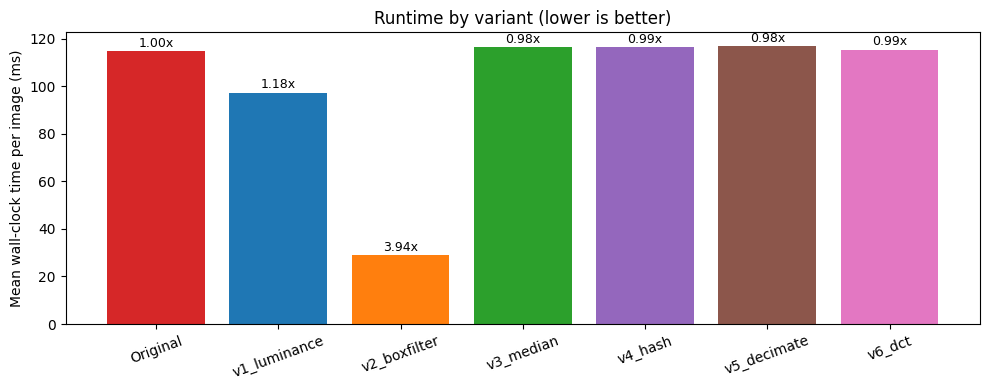

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#d62728", "#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#8c564b", "#e377c2"]
bars = ax.bar(rt_df["Variant"], rt_df["Mean (ms)"], color=colors)

for bar, spd in zip(bars, rt_df["Speedup"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{spd:.2f}x", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Mean wall-clock time per image (ms)")
ax.set_title("Runtime by variant (lower is better)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "runtime_by_variant.png", dpi=150)
plt.show()

---
## Step 3 — Peak Memory

Peak heap allocation per hash call measured with . Reported as the peak memory usage (in KB) above the baseline captured before each call.

In [33]:
mem_images = random.sample(all_images, 10)
mem_records = []

for label, hasher in VARIANTS:
    peaks = []
    for img_path in mem_images:
        tracemalloc.start()
        hasher.fromFile(str(img_path))
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        peaks.append(peak / 1024)  # bytes → KB
    mean_kb = round(statistics.mean(peaks), 1)
    mem_records.append({"Variant": label, "Peak memory (KB)": mean_kb})
    print(f"{label:<15}: {mean_kb:7.1f} KB")

mem_df = pd.DataFrame(mem_records)

Original       :  3990.5 KB
v1_luminance   :  4439.5 KB
v2_boxfilter   :  8855.5 KB
v3_median      :  3990.1 KB
v4_hash        :  3990.0 KB
v5_decimate    :  4568.7 KB
v6_dct         :  4031.3 KB


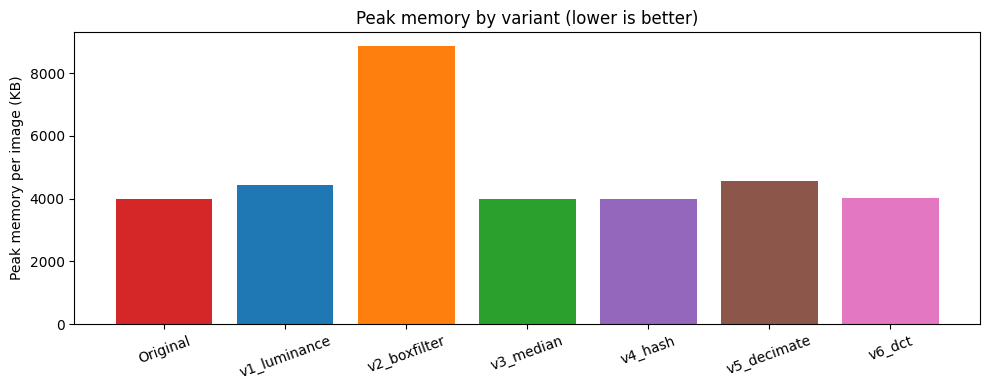

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(mem_df["Variant"], mem_df["Peak memory (KB)"], color=colors)
ax.set_ylabel("Peak memory per image (KB)")
ax.set_title("Peak memory by variant (lower is better)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "memory_by_variant.png", dpi=150)
plt.show()

---
## Step 4 — cProfile

Function-level profiling for each variant on a single image, 5 repetitions. Shows the top 8 cumulative-time functions to identify where time is spent.

In [45]:
img_path = str(random.choice(all_images))
REPS = 5

for label, hasher in VARIANTS:
    pr = cProfile.Profile()
    pr.enable()
    for _ in range(REPS):
        hasher.fromFile(img_path)
    pr.disable()
    buf = io.StringIO()
    ps = pstats.Stats(pr, stream=buf).sort_stats("cumulative")
    ps.print_stats(8)
    lines = buf.getvalue().splitlines()
    print(f"\n=== {label} ===")
    print("\n".join(lines[4:14]))


=== Original ===

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      6/5    0.003    0.001    0.984    0.197 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd.py:39(fromFile)
        5    0.000    0.000    0.980    0.196 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd.py:47(fromImage)
        5    0.000    0.000    0.619    0.124 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd.py:79(findHash256FromFloatLuma)
        5    0.514    0.103    0.607    0.121 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd.py:167(boxFilter)
        5    0.053    0.011    0.351    0.070 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd.py:66(fillFloatLumaFromBufferImage)
   312500    0.083    0.000    0.303    0.000 /opt/anaconda3/envs/FSDS/lib/python3.12/site-packages/PIL/Image.py:1631(getpixel)
   312520    0.074    0.000    0.154    0.000 /opt/anaconda3/envs/FSDS/lib/python3.12/site-p

---
## Step 5 — Summary & Selection

Consolidated results. 

In [ ]:
summary = rt_df.merge(mem_df, on="Variant")
print("=== Consolidated Summary ===")
print(summary.to_string(index=False))

best = summary.loc[summary["Speedup"].idxmax()]
print(f"Best variant by speedup: {best['Variant']} ({best['Speedup']}x faster, "
      f"{best['Peak memory (KB)']} KB peak memory)")

=== Consolidated Summary ===
     Variant  Mean (ms)  Median (ms)  Speedup  Peak memory (KB)
    Original     114.65       114.54     1.00            3990.5
v1_luminance      97.36        97.11     1.18            4439.5
v2_boxfilter      29.07        29.02     3.94            8855.5
   v3_median     116.51       116.65     0.98            3990.1
     v4_hash     116.35       116.18     0.99            3990.0
 v5_decimate     116.86       116.62     0.98            4568.7
      v6_dct     115.43       115.45     0.99            4031.3
Best variant by speedup: v2_boxfilter (3.94x faster, 8855.5 KB peak memory)


---
## Combination Variants

Three combined versions apply multiple optimisations simultaneously to measure cumulative speedup. Each is tested for correctness first, then profiled identically to the individual variants above.

In [38]:
from optimisations.v1_v2  import FINDHasher_v1_v2
from optimisations.all_v2 import FINDHasher_all_v2
from optimisations.all    import FINDHasher_all

COMBOS = [
    ("v1+v2",    FINDHasher_v1_v2()),
    ("all-v2",   FINDHasher_all_v2()),
    ("all",      FINDHasher_all()),
]
print(f"Combination variants loaded: {[c[0] for c in COMBOS]}")

Combination variants loaded: ['v1+v2', 'all-v2', 'all']


### Correctness Check — Combination Variants


In [39]:
orig_hasher2 = FINDHasher()
print(f"Testing {len(test_images)} images...\n")
combo_pass = True
for label, hasher in COMBOS:
    dists = [orig_hasher2.fromFile(str(p)) - hasher.fromFile(str(p))
             for p in test_images]
    non_zero = [d for d in dists if d != 0]
    status = "PASS" if not non_zero else f"FAIL — non-zero distances: {set(non_zero)}"
    if non_zero:
        combo_pass = False
    print(f"{label:<10}: {status}")
print()
print("All combinations correct." if combo_pass else "WARNING: one or more combinations failed.")

Testing 20 images...

v1+v2     : PASS
all-v2    : PASS
all       : PASS

All combinations correct.


### Runtime — Combination Variants

Same protocol as individual variants: `timeit.repeat` with 5 repeats, minimum taken, over 20 images.

In [40]:
combo_rt_records = []

for label, hasher in COMBOS:
    timings = []
    for img_path in bench_images:
        t = timeit.repeat(
            lambda p=str(img_path), h=hasher: h.fromFile(p),
            number=1, repeat=REPEATS
        )
        timings.append(min(t))
    mean_ms   = statistics.mean(timings) * 1000
    median_ms = statistics.median(timings) * 1000
    combo_rt_records.append({"Variant": label, "Mean (ms)": round(mean_ms, 2),
                              "Median (ms)": round(median_ms, 2)})
    print(f"{label:<10}: mean={mean_ms:6.1f} ms  median={median_ms:6.1f} ms")

combo_rt_df = pd.DataFrame(combo_rt_records)
combo_rt_df["Speedup"] = (baseline / combo_rt_df["Mean (ms)"]).round(2)
print()
print(combo_rt_df.to_string(index=False))

v1+v2     : mean=  11.7 ms  median=  11.7 ms
all-v2    : mean=  94.0 ms  median=  93.8 ms
all       : mean=  10.9 ms  median=  10.8 ms

Variant  Mean (ms)  Median (ms)  Speedup
  v1+v2      11.72        11.68     9.78
 all-v2      93.97        93.76     1.22
    all      10.93        10.85    10.49


### Peak Memory — Combination Variants

Same protocol as individual variants: `tracemalloc` peak over 10 images.

In [41]:
combo_mem_records = []

for label, hasher in COMBOS:
    peaks = []
    for img_path in mem_images:
        tracemalloc.start()
        hasher.fromFile(str(img_path))
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        peaks.append(peak / 1024)
    mean_kb = round(statistics.mean(peaks), 1)
    combo_mem_records.append({"Variant": label, "Peak memory (KB)": mean_kb})
    print(f"{label:<10}: {mean_kb:7.1f} KB")

combo_mem_df = pd.DataFrame(combo_mem_records)

v1+v2     :  8855.9 KB
all-v2    :  4568.8 KB
all       :  8855.6 KB


### cProfile — Combination Variants

Top 8 cumulative-time functions per combination on 5 repetitions of a single image.

In [42]:
for label, hasher in COMBOS:
    pr = cProfile.Profile()
    pr.enable()
    for _ in range(REPS):
        hasher.fromFile(img_path)
    pr.disable()
    buf = io.StringIO()
    ps = pstats.Stats(pr, stream=buf).sort_stats("cumulative")
    ps.print_stats(8)
    lines = buf.getvalue().splitlines()
    print(f"\n=== {label} ===")
    print("\n".join(lines[4:14]))


=== v1+v2 ===

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      6/5    0.004    0.001    0.091    0.018 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/optimisations/v1_v2.py:45(fromFile)
        5    0.002    0.000    0.087    0.017 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/optimisations/v1_v2.py:53(fromImage)
        5    0.000    0.000    0.052    0.010 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/optimisations/v1_v2.py:87(findHash256FromFloatLuma)
        5    0.032    0.006    0.040    0.008 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/optimisations/v1_v2.py:176(boxFilter)
        5    0.028    0.006    0.031    0.006 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/optimisations/v1_v2.py:73(fillFloatLumaFromBufferImage)
        5    0.009    0.002    0.009    0.002 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/optimisations/v1_v2.py:118(dct64To16)
 

---
## Final Summary — All Variants

Consolidated table covering all 6 individual variants and all 3 combination variants, ranked by speedup. 

In [44]:
# Merge runtime and memory for individual variants
ind_summary = rt_df.merge(mem_df, on="Variant")

# Merge for combinations
comb_summary = combo_rt_df.merge(combo_mem_df, on="Variant")

# Stack all together
full_summary = pd.concat([ind_summary, comb_summary], ignore_index=True)
full_summary = full_summary.sort_values("Speedup", ascending=False).reset_index(drop=True)

print("=" * 65)
print(f"  {'Variant':<15} {'Mean (ms)':>10} {'Median (ms)':>12} {'Speedup':>8} {'Peak (KB)':>10}")
print("=" * 65)
for _, row in full_summary.iterrows():
    print(f"  {row['Variant']:<15} {row['Mean (ms)']:>10.2f} {row['Median (ms)']:>12.2f} "
          f"{row['Speedup']:>8.2f}x {row['Peak memory (KB)']:>10.1f}{marker}")
print("=" * 65)

best = full_summary.iloc[0]
print(f"\nRecommended variant: {best['Variant']}")
print(f"  Speedup:      {best['Speedup']}x faster than original")
print(f"  Mean time:    {best['Mean (ms)']} ms per image")
print(f"  Peak memory:  {best['Peak memory (KB)']} KB per image")

  Variant          Mean (ms)  Median (ms)  Speedup  Peak (KB)
  all                  10.93        10.85    10.49x     8855.6
  v1+v2                11.72        11.68     9.78x     8855.9
  v2_boxfilter         29.07        29.02     3.94x     8855.5
  all-v2               93.97        93.76     1.22x     4568.8
  v1_luminance         97.36        97.11     1.18x     4439.5
  Original            114.65       114.54     1.00x     3990.5
  v4_hash             116.35       116.18     0.99x     3990.0
  v6_dct              115.43       115.45     0.99x     4031.3
  v3_median           116.51       116.65     0.98x     3990.1
  v5_decimate         116.86       116.62     0.98x     4568.7

Recommended variant: all
  Speedup:      10.49x faster than original
  Mean time:    10.93 ms per image
  Peak memory:  8855.6 KB per image


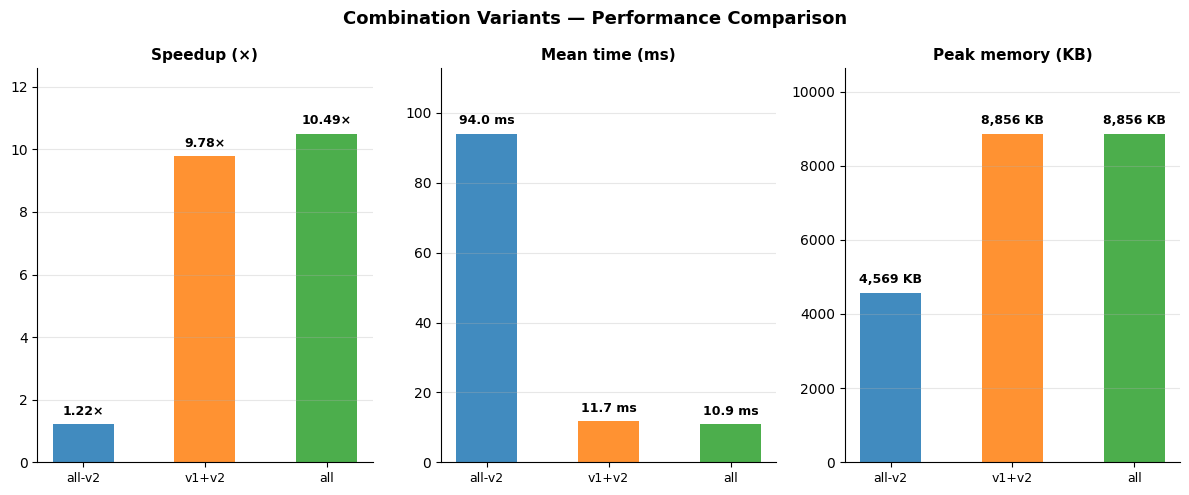

In [56]:
combos = full_summary[full_summary['Variant'].isin(['all-v2', 'v1+v2', 'all'])].copy()
combos = combos.set_index('Variant').loc[['all-v2', 'v1+v2', 'all']].reset_index()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']   # blue, orange, green — same as scaling chart

metrics = [
    ('Speedup',           'Speedup (×)',      '{:.2f}×'),
    ('Mean (ms)',         'Mean time (ms)',   '{:.1f} ms'),
    ('Peak memory (KB)', 'Peak memory (KB)', '{:,.0f} KB'),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, (col, title, fmt) in zip(axes, metrics):
    bars = ax.bar(combos['Variant'], combos[col], color=colors, width=0.5, alpha=0.85)

    for bar, val in zip(bars, combos[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + combos[col].max() * 0.02,
                fmt.format(val),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylim(0, combos[col].max() * 1.2)
    ax.tick_params(axis='x', labelsize=9)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Combination Variants — Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'combo_three_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
